In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from math import log
import operator
import random
from random import randrange
from collections import Counter
from sklearn.metrics import roc_auc_score

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

train_set = pd.read_csv('adult.data', header=None, names=columns, skipinitialspace=True)
test_set = pd.read_csv('adult.test', header=None, names=columns, skipinitialspace=True, skipfooter=1, engine='python')

print("=== 训练集信息 ===")
print(f"形状: {train_set.shape}")
print(f"\n数据类型:\n{train_set.dtypes}")
print(f"\n前5行:\n{train_set.head()}")

print("\n=== 测试集信息 ===")
print(f"形状: {test_set.shape}")
print(f"\n数据类型:\n{test_set.dtypes}")
print(f"\n前5行:\n{test_set.head()}")

=== 训练集信息 ===
形状: (32561, 15)

数据类型:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

前5行:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial       

In [2]:
# 处理缺失值：去掉含有 '?' 的行
# 注意：问号前可能有空格，但 skipinitialspace=True 已经处理了前缀空格

print("处理缺失值前：")
print(f"训练集行数: {len(train_set)}")
print(f"测试集行数: {len(test_set)}")

# 检查每列是否有 '?'，并删除含 '?' 的行
for col in train_set.columns:
    train_set = train_set[train_set[col] != '?']
    test_set = test_set[test_set[col] != '?']

# 重新设置索引（删除行后索引不连续）
train_set.index = range(0, len(train_set))
test_set.index = range(0, len(test_set))

print("\n处理缺失值后：")
print(f"训练集行数: {len(train_set)}")
print(f"测试集行数: {len(test_set)}")

# 看看 income 列的值，确认训练集和测试集的格式
print(f"\n训练集 income 取值:\n{train_set['income'].value_counts()}")
print(f"\n测试集 income 取值:\n{test_set['income'].value_counts()}")

处理缺失值前：
训练集行数: 32561
测试集行数: 16282

处理缺失值后：
训练集行数: 30162
测试集行数: 15061

训练集 income 取值:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64

测试集 income 取值:
income
<=50K.    11360
>50K.      3700
Name: count, dtype: int64


In [3]:
# 3.1 删除 fnlwgt 列（序号权重，不影响分类）
train_set.drop(labels='fnlwgt', axis=1, inplace=True)
test_set.drop(labels='fnlwgt', axis=1, inplace=True)

# 3.2 删除 education 列（与 education-num 重复）
train_set.drop(labels='education', axis=1, inplace=True)
test_set.drop(labels='education', axis=1, inplace=True)

# 3.3 处理测试集 income 后面的点号
test_set['income'] = test_set['income'].str.replace('.', '', regex=False)

print("删除列并处理标签后：")
print(f"训练集列: {list(train_set.columns)}")
print(f"训练集形状: {train_set.shape}")
print(f"测试集形状: {test_set.shape}")

print(f"\n测试集 income 取值:\n{test_set['income'].value_counts()}")

# 记录训练集和测试集的行数，后面要用
m = len(train_set)  # 训练集行数
n = len(test_set)   # 测试集行数
print(f"\nm = {m}, n = {n}")

删除列并处理标签后：
训练集列: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
训练集形状: (30162, 13)
测试集形状: (15061, 13)

测试集 income 取值:
income
<=50K    11360
>50K      3700
Name: count, dtype: int64

m = 30162, n = 15061


In [9]:
# 删除测试集中的脏数据行（age 不是数字的行）
test_set = test_set[pd.to_numeric(test_set['age'], errors='coerce').notna()]
test_set.index = range(0, len(test_set))

# 更新 n
n = len(test_set)

print(f"清理后测试集行数: {n}")
print(f"测试集前5行:\n{test_set.head()}")

# 4.1 将 age 划分为 4 个区间
age = np.copy(train_set['age']).astype(int)
age_test = np.copy(test_set['age']).astype(int)

def transform1(age, size):
    for i in range(size):
        if age[i] >= 0 and age[i] < 25:
            age[i] = 0
        elif age[i] >= 25 and age[i] < 50:
            age[i] = 1
        elif age[i] >= 50 and age[i] < 75:
            age[i] = 2
        elif age[i] >= 75:
            age[i] = 3
    return age

age = transform1(age, m)
age_test = transform1(age_test, n)

train_set['age'] = age
test_set['age'] = age_test

print("\nage 离散化后：")
print(f"训练集 age 取值:\n{train_set['age'].value_counts().sort_index()}")
print(f"\n测试集 age 取值:\n{test_set['age'].value_counts().sort_index()}")

清理后测试集行数: 15060
测试集前5行:
  age  workclass  education-num      marital-status         occupation  \
0  25    Private            7.0       Never-married  Machine-op-inspct   
1  38    Private            9.0  Married-civ-spouse    Farming-fishing   
2  28  Local-gov           12.0  Married-civ-spouse    Protective-serv   
3  44    Private           10.0  Married-civ-spouse  Machine-op-inspct   
4  34    Private            6.0       Never-married      Other-service   

    relationship   race   sex  capital-gain  capital-loss  hours-per-week  \
0      Own-child  Black  Male           0.0           0.0            40.0   
1        Husband  White  Male           0.0           0.0            50.0   
2        Husband  White  Male           0.0           0.0            40.0   
3        Husband  Black  Male        7688.0           0.0            40.0   
4  Not-in-family  White  Male           0.0           0.0            30.0   

  native-country income  
0  United-States  <=50K  
1  United-States

In [10]:
# 4.2 处理 capital-gain：>0 的值用 1 替换，=0 的值用 0 替换
gain = np.copy(train_set['capital-gain']).astype(int)
gain_test = np.copy(test_set['capital-gain']).astype(int)

def transform2(gain, size):
    for i in range(size):
        if gain[i] == 0:
            gain[i] = 0
        elif gain[i] > 0:
            gain[i] = 1
    return gain

gain = transform2(gain, m)
gain_test = transform2(gain_test, n)

train_set['capital-gain'] = gain
test_set['capital-gain'] = gain_test

print("capital-gain 二值化后：")
print(f"训练集: {train_set['capital-gain'].value_counts().to_dict()}")
print(f"测试集: {test_set['capital-gain'].value_counts().to_dict()}")

# 4.3 处理 capital-loss：同样二值化
loss = np.copy(train_set['capital-loss']).astype(int)
loss_test = np.copy(test_set['capital-loss']).astype(int)

loss = transform2(loss, m)
loss_test = transform2(loss_test, n)

train_set['capital-loss'] = loss
test_set['capital-loss'] = loss_test

print("\ncapital-loss 二值化后：")
print(f"训练集: {train_set['capital-loss'].value_counts().to_dict()}")
print(f"测试集: {test_set['capital-loss'].value_counts().to_dict()}")

capital-gain 二值化后：
训练集: {0: 27624, 1: 2538}
测试集: {0: 13808, 1: 1252}

capital-loss 二值化后：
训练集: {0: 28735, 1: 1427}
测试集: {0: 14347, 1: 713}


In [11]:
# 4.4 将 hours-per-week 划分为 <40, ==40, >40 三类
hours = np.copy(train_set['hours-per-week']).astype(int)
hours_test = np.copy(test_set['hours-per-week']).astype(int)

def transform3(hours, size):
    for i in range(size):
        if hours[i] < 40:
            hours[i] = 0
        elif hours[i] == 40:
            hours[i] = 1
        elif hours[i] > 40:
            hours[i] = 2
    return hours

hours = transform3(hours, m)
hours_test = transform3(hours_test, n)

train_set['hours-per-week'] = hours
test_set['hours-per-week'] = hours_test

print("hours-per-week 离散化后：")
print(f"训练集: {train_set['hours-per-week'].value_counts().sort_index().to_dict()}")
print(f"测试集: {test_set['hours-per-week'].value_counts().sort_index().to_dict()}")

hours-per-week 离散化后：
训练集: {0: 6714, 1: 14251, 2: 9197}
测试集: {0: 3373, 1: 7107, 2: 4580}


In [12]:
# 4.5 将 native-country 划分为 USA 和 not USA 两类
# 注意：值前面可能有空格
cty = np.copy(train_set['native-country'])
cty_test = np.copy(test_set['native-country'])

def transform4(cty, size):
    for i in range(size):
        # 去掉前后空格再比较
        val = str(cty[i]).strip()
        if val == "United-States":
            cty[i] = 0
        else:
            cty[i] = 1
    return cty

cty = transform4(cty, m)
cty_test = transform4(cty_test, n)

train_set['native-country'] = cty
test_set['native-country'] = cty_test

print("native-country 二值化后：")
print(f"训练集: {train_set['native-country'].value_counts().to_dict()}")
print(f"测试集: {test_set['native-country'].value_counts().to_dict()}")

native-country 二值化后：
训练集: {0: 27504, 1: 2658}
测试集: {0: 13788, 1: 1272}


In [13]:
# 4.6 将 workclass 分为 Freelance、other、Proprietor、Private、Government 五类
# Freelance、other、Private 是本身就有的类，不做处理
workclass = np.copy(train_set['workclass'])
workclass_test = np.copy(test_set['workclass'])

def transform6(workclass, size):
    for i in range(size):
        val = str(workclass[i]).strip()
        # 政府类合并
        if val in ["Federal-gov", "Local-gov", "State-gov"]:
            workclass[i] = "Government"
        # 自雇类合并为 Proprietor
        elif val in ["Self-emp-not-inc", "Self-emp-inc"]:
            workclass[i] = "Proprietor"
        # 其他的保持不变（Freelance、other、Private等）
        else:
            workclass[i] = val
    return workclass

workclass = transform6(workclass, m)
workclass_test = transform6(workclass_test, n)

train_set['workclass'] = workclass
test_set['workclass'] = workclass_test

print("workclass 合并后：")
print(f"训练集:\n{train_set['workclass'].value_counts()}")
print(f"\n测试集:\n{test_set['workclass'].value_counts()}")

workclass 合并后：
训练集:
workclass
Private        22286
Government      4289
Proprietor      3573
Without-pay       14
Name: count, dtype: int64

测试集:
workclass
Private        11021
Government      2163
Proprietor      1869
Without-pay        7
Name: count, dtype: int64


In [14]:
# 4.7 将 education-num 分为 0-5:0, 5-10:1, >=10:2
edu = np.copy(train_set['education-num']).astype(int)
edu_test = np.copy(test_set['education-num']).astype(int)

def transform5(edu, size):
    for i in range(size):
        if edu[i] < 5:
            edu[i] = 0
        elif edu[i] >= 5 and edu[i] < 10:
            edu[i] = 1
        elif edu[i] >= 10:
            edu[i] = 2
    return edu

edu = transform5(edu, m)
edu_test = transform5(edu_test, n)

train_set['education-num'] = edu
test_set['education-num'] = edu_test

print("education-num 离散化后：")
print(f"训练集: {train_set['education-num'].value_counts().sort_index().to_dict()}")
print(f"测试集: {test_set['education-num'].value_counts().sort_index().to_dict()}")

education-num 离散化后：
训练集: {0: 1041, 1: 12540, 2: 16581}
测试集: {0: 525, 1: 6338, 2: 8197}


In [15]:
# 4.8 将 marital-status 分为 married 和 not-married 两类
mari = np.copy(train_set['marital-status'])
mari_test = np.copy(test_set['marital-status'])

def transform8(mari, size):
    for i in range(size):
        val = str(mari[i]).strip()
        # 离婚、未婚、分居、丧偶 → not-married
        if val in ["Divorced", "Never-married", "Separated", "Widowed"]:
            mari[i] = "not-married"
        # 其他（已婚类）→ married
        else:
            mari[i] = "married"
    return mari

mari = transform8(mari, m)
mari_test = transform8(mari_test, n)

train_set['marital-status'] = mari
test_set['marital-status'] = mari_test

print("marital-status 合并后：")
print(f"训练集:\n{train_set['marital-status'].value_counts()}")
print(f"\n测试集:\n{test_set['marital-status'].value_counts()}")

marital-status 合并后：
训练集:
marital-status
not-married    15706
married        14456
Name: count, dtype: int64

测试集:
marital-status
not-married    7877
married        7183
Name: count, dtype: int64


In [16]:
# 4.9 将 occupation 分为 High、Med、Low 三类
occu = np.copy(train_set['occupation'])
occu_test = np.copy(test_set['occupation'])

def transform9(occu, size):
    for i in range(size):
        val = str(occu[i]).strip()
        # 高级职业
        if val in ["Prof-specialty", "Exec-managerial"]:
            occu[i] = "High"
        # 中级职业
        elif val in ["Tech-support", "Transport-moving", "Protective-serv", 
                     "Sales", "Craft-repair", "Armed-Forces"]:
            occu[i] = "Med"
        # 其他 → 低级职业
        else:
            occu[i] = "Low"
    return occu

occu = transform9(occu, m)
occu_test = transform9(occu_test, n)

train_set['occupation'] = occu
test_set['occupation'] = occu_test

print("occupation 合并后：")
print(f"训练集:\n{train_set['occupation'].value_counts()}")
print(f"\n测试集:\n{test_set['occupation'].value_counts()}")

occupation 合并后：
训练集:
occupation
Low     11381
Med     10751
High     8030
Name: count, dtype: int64

测试集:
occupation
Low     5695
Med     5403
High    3962
Name: count, dtype: int64


In [17]:
# 4.10 将 relationship 分为 Husband、Other、Wife
reship = np.copy(train_set['relationship'])
reship_test = np.copy(test_set['relationship'])

def transform7(reship, size):
    for i in range(size):
        val = str(reship[i]).strip()
        # 不是 Husband 也不是 Wife → Other
        if val != "Husband" and val != "Wife":
            reship[i] = "Other"
        # 否则保持原值（Husband 或 Wife）
        else:
            reship[i] = val
    return reship

reship = transform7(reship, m)
reship_test = transform7(reship_test, n)

train_set['relationship'] = reship
test_set['relationship'] = reship_test

print("relationship 合并后：")
print(f"训练集:\n{train_set['relationship'].value_counts()}")
print(f"\n测试集:\n{test_set['relationship'].value_counts()}")

relationship 合并后：
训练集:
relationship
Other      16293
Husband    12463
Wife        1406
Name: count, dtype: int64

测试集:
relationship
Other      8172
Husband    6203
Wife        685
Name: count, dtype: int64


In [18]:
# 4.11 将 race 分为 White 和 Other 两类
race = np.copy(train_set['race'])
race_test = np.copy(test_set['race'])

def transform10(race, size):
    for i in range(size):
        val = str(race[i]).strip()
        # 不是 White → Other
        if val != "White":
            race[i] = "Other"
        # 是 White → 保持 White
        else:
            race[i] = val
    return race

race = transform10(race, m)
race_test = transform10(race_test, n)

train_set['race'] = race
test_set['race'] = race_test

print("race 合并后：")
print(f"训练集:\n{train_set['race'].value_counts()}")
print(f"\n测试集:\n{test_set['race'].value_counts()}")

race 合并后：
训练集:
race
White    25933
Other     4229
Name: count, dtype: int64

测试集:
race
White    12970
Other     2090
Name: count, dtype: int64


In [19]:
# 4.12 将 sex 编码为 0/1
# Male → 0, Female → 1（或者反过来，只要统一就行）
sex = np.copy(train_set['sex'])
sex_test = np.copy(test_set['sex'])

def transform_sex(sex, size):
    for i in range(size):
        val = str(sex[i]).strip()
        if val == "Male":
            sex[i] = 0
        elif val == "Female":
            sex[i] = 1
    return sex

sex = transform_sex(sex, m)
sex_test = transform_sex(sex_test, n)

train_set['sex'] = sex
test_set['sex'] = sex_test

print("sex 编码后：")
print(f"训练集: {train_set['sex'].value_counts().to_dict()}")
print(f"测试集: {test_set['sex'].value_counts().to_dict()}")

sex 编码后：
训练集: {0: 20380, 1: 9782}
测试集: {0: 10147, 1: 4913}


In [20]:
# 5) 对 income 属性列（标签列）进行标签编码
label_encoder = LabelEncoder()

# 训练集：fit_transform
train_set['income'] = label_encoder.fit_transform(train_set['income'])
# 测试集：用同一个 encoder transform（保证编码一致）
test_set['income'] = label_encoder.transform(test_set['income'])

print("income 标签编码后：")
print(f"训练集: {train_set['income'].value_counts().to_dict()}")
print(f"测试集: {test_set['income'].value_counts().to_dict()}")
print(f"\n标签映射: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# 将测试集和训练集转为列表格式，并分离标签
y_test = test_set['income'].values.tolist()
y_train = train_set['income'].values.tolist()

# 数据集转为列表（保留特征+标签）
test_set_list = test_set.values.tolist()
train_set_list = train_set.values.tolist()

print(f"\ny_train 长度: {len(y_train)}, y_test 长度: {len(y_test)}")
print(f"train_set_list 长度: {len(train_set_list)}, 每行长度: {len(train_set_list[0])}")
print(f"test_set_list 长度: {len(test_set_list)}, 每行长度: {len(test_set_list[0])}")

income 标签编码后：
训练集: {0: 22654, 1: 7508}
测试集: {0: 11360, 1: 3700}

标签映射: {'<=50K': np.int64(0), '>50K': np.int64(1)}

y_train 长度: 30162, y_test 长度: 15060
train_set_list 长度: 30162, 每行长度: 13
test_set_list 长度: 15060, 每行长度: 13


In [21]:
print("=== 训练集前5行 ===")
print(train_set.head())

print("\n=== 测试集前5行 ===")
print(test_set.head())

print("\n=== 训练集信息 ===")
print(train_set.info())

print("\n=== 测试集信息 ===")
print(test_set.info())

print("\n=== 各列数据类型 ===")
print(train_set.dtypes)

=== 训练集前5行 ===
   age   workclass  education-num marital-status occupation relationship  \
0    1  Government              2    not-married        Low        Other   
1    2  Proprietor              2        married       High      Husband   
2    1     Private              1    not-married        Low        Other   
3    2     Private              1        married        Low      Husband   
4    1     Private              2        married       High         Wife   

    race sex  capital-gain  capital-loss  hours-per-week native-country  \
0  White   0             1             0               1              0   
1  White   0             0             0               0              0   
2  White   0             0             0               1              0   
3  Other   0             0             0               1              0   
4  Other   1             0             0               1              1   

   income  
0       0  
1       0  
2       0  
3       0  
4       0  

=== 

In [22]:
# 创建数据集和特征名称
def createDataSet():
    dataSet = train_set.values.tolist()
    featureName = ['age', 'workclass', 'education-num', 'marital-status', 
                   'occupation', 'relationship', 'race', 'sex', 
                   'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
    return dataSet, featureName

# 按照给定特征划分数据集
# axis: 特征维度索引, value: 该特征的某个取值
def splitDataSet(dataSet, axis, value):
    retDataSet = []
    for featVec in dataSet:
        if featVec[axis] == value:  # 只取该特征值等于 value 的样本
            # 删除这一维特征（已用于划分，不再参与后续分裂）
            reduceFeatVec = featVec[:axis]
            reduceFeatVec.extend(featVec[axis+1:])
            retDataSet.append(reduceFeatVec)
    return retDataSet

In [23]:
# 计算训练数据集的香农熵（信息熵）
def calcShannonEnt(dataSet):
    numEntries = len(dataSet)  # 样本总数
    labelCounts = {}  # 统计每个标签出现的次数
    
    for featVec in dataSet:
        currentLabel = featVec[-1]  # 最后一列是标签
        if currentLabel not in labelCounts.keys():
            labelCounts[currentLabel] = 0
        labelCounts[currentLabel] += 1
    
    shannonEnt = 0.0
    for key in labelCounts:
        prob = float(labelCounts[key]) / numEntries  # 该标签的概率
        shannonEnt -= prob * log(prob, 2)  # H = -Σ p*log₂(p)
    
    return shannonEnt

In [24]:
# 计算条件熵 H(Y|X_i)
# 即：在已知特征 X_i 的条件下，标签 Y 的不确定性
def calcConditionalEntropy(dataSet, i, featList, uniqueVals):
    """
    dataSet: 数据集
    i: 特征维度索引
    featList: 第i维的所有取值列表
    uniqueVals: 第i维的唯一取值集合
    """
    ce = 0.0
    for value in uniqueVals:
        # 按该特征值划分出子数据集
        subDataSet = splitDataSet(dataSet, i, value)
        # 极大似然估计：该特征值出现的概率
        prob = len(subDataSet) / float(len(dataSet))
        # 累加：p * H(子数据集)
        ce += prob * calcShannonEnt(subDataSet)
    return ce

In [25]:
# 计算信息增益 G(D, A) = H(D) - H(D|A)
def calcInformationGain(dataSet, baseEntropy, i):
    """
    dataSet: 数据集
    baseEntropy: 数据集D的信息熵 H(D)
    i: 特征维度索引
    """
    # 第i维的所有取值列表
    featList = [example[i] for example in dataSet]
    # 唯一取值集合
    uniqueVals = set(featList)
    # 计算条件熵 H(D|X_i)
    newEntropy = calcConditionalEntropy(dataSet, i, featList, uniqueVals)
    # 信息增益 = 信息熵 - 条件熵
    infoGain = baseEntropy - newEntropy
    return infoGain

In [26]:
# 选择最好的数据特征划分，返回最佳特征对应的维度索引
def chooseBestFeatureToSplitByID3(dataSet):
    numFeatures = len(dataSet[0]) - 1  # 最后一列是标签，不算特征
    baseEntropy = calcShannonEnt(dataSet)  # 数据集原始熵
    bestInfoGain = 0.0
    bestFeature = -2  # 初始化为-2，避免和-1（最后一列）混淆
    
    for i in range(numFeatures):  # 遍历所有特征
        infoGain = calcInformationGain(dataSet, baseEntropy, i)
        # print(f"特征{i}的信息增益: {infoGain}")  # 调试用
        if infoGain > bestInfoGain:
            bestInfoGain = infoGain
            bestFeature = i
    
    return bestFeature  # 返回最佳特征的索引


# 计算 classList 中出现次数最多的元素（多数表决）
def majorityCnt(classList):
    classCount = {}
    for vote in classList:
        if vote not in classCount.keys():
            classCount[vote] = 0
        classCount[vote] += 1
    
    # 按出现次数降序排序，返回最多的那个
    sortedClassCount = sorted(classCount.items(), key=operator.itemgetter(1), reverse=True)
    return sortedClassCount[0][0]

In [27]:
# 创建决策树
def createTree(dataSet, featureName, chooseBestFeatureToSplitFunc=chooseBestFeatureToSplitByID3):
    """
    dataSet: 数据集
    featureName: 数据集每一维的名称列表
    """
    classList = [example[-1] for example in dataSet]  # 当前数据集的类别列表
    
    # 停止条件1：所有样本类别完全相同
    if classList.count(classList[0]) == len(classList):
        return classList[0]
    
    # 停止条件2：只剩最后一列（类别列），没有特征可分了
    if len(dataSet[0]) == 1:
        return majorityCnt(classList)
    
    # 选择最优划分特征
    bestFeat = chooseBestFeatureToSplitFunc(dataSet)
    bestFeatLabel = featureName[bestFeat]
    
    # 用字典存储树结构
    myTree = {bestFeatLabel: {}}
    
    # 从特征名列表中删除该特征（已用过，子树不再用）
    del(featureName[bestFeat])
    
    # 获取该特征的所有唯一取值
    featValues = [example[bestFeat] for example in dataSet]
    uniqueVals = set(featValues)
    
    # 对每个取值，递归构建子树
    for value in uniqueVals:
        # 复制特征名列表（因为每分支要独立删除用过的特征）
        subLabels = featureName[:]
        myTree[bestFeatLabel][value] = createTree(
            splitDataSet(dataSet, bestFeat, value),  # 划分后的子数据集
            subLabels,  # 删除当前特征后的特征名
            chooseBestFeatureToSplitFunc
        )
    
    return myTree

In [28]:
# 使用决策树对单个样本进行分类
def classify(inputTree, featLabels, testVec):
    """
    inputTree: 决策树字典
    featLabels: 特征名称列表（完整版，用于找索引）
    testVec: 单个测试样本
    """
    # 获取树的第一个键（当前结点要判断的特征）
    firstStr = list(inputTree.keys())[0]
    secondDict = inputTree[firstStr]
    
    # 在特征列表中找到该特征的索引
    featIndex = featLabels.index(firstStr)
    
    # 测试样本在该特征上的取值
    key = testVec[featIndex]
    
    # 如果该取值不在树中存在（训练时没见过的值），用第一个存在的分支代替
    if key not in secondDict:
        key = list(secondDict.keys())[0]
    
    valueOfFeat = secondDict[key]
    
    # 如果值是字典，说明还没到叶结点，继续递归
    if isinstance(valueOfFeat, dict):
        classLabel = classify(valueOfFeat, featLabels, testVec)
    else:
        # 到达叶结点，返回类别
        classLabel = valueOfFeat
    
    return classLabel

In [29]:
# 构建决策树
dataSet, featureName = createDataSet()
# 复制一份特征名，因为 createTree 会修改 featureName
featureName_copy = featureName[:]
myTree = createTree(dataSet, featureName_copy)

print("决策树构建完成！")
print(f"树结构（前3层预览）: {str(myTree)[:500]}...")

# 定义完整的特征名列表（用于 classify 找索引）
featLabels = ['age', 'workclass', 'education-num', 'marital-status', 
              'occupation', 'relationship', 'race', 'sex', 
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# 在测试集上预测
classList = []
for i in range(len(test_set_list)):
    classLabel = classify(myTree, featLabels, test_set_list[i])
    classList.append(classLabel)

# 在训练集上预测（用于判断是否过拟合）
classList_train = []
for i in range(len(train_set_list)):
    classLabel = classify(myTree, featLabels, train_set_list[i])
    classList_train.append(classLabel)

# 计算测试集准确率
correct_num = 0
for i in range(n):
    if classList[i] == y_test[i]:
        correct_num += 1
rate = correct_num / n
print(f"\n决策树测试集准确率: {rate}")

# 计算训练集准确率
correct_num_train = 0
for i in range(m):
    if classList_train[i] == y_train[i]:
        correct_num_train += 1
rate_train = correct_num_train / m
print(f"决策树训练集准确率: {rate_train}")

# 计算 AUC
auc_score = roc_auc_score(y_test, classList)
print(f"决策树 AUC 值: {auc_score}")

决策树构建完成！
树结构（前3层预览）: {'relationship': {'Other': {'occupation': {'Low': {'capital-gain': {0: {'hours-per-week': {0: {'age': {0: {'education-num': {0: 0, 1: 0, 2: {'sex': {0: {'race': {'Other': 0, 'White': {'workclass': {'Proprietor': 0, 'Government': 0, 'Private': {'native-country': {0: {'capital-loss': {0: {'marital-status': {'not-married': 0}}, 1: 0}}, 1: 0}}}}}}, 1: 0}}}}, 1: {'capital-loss': {0: {'race': {'Other': 0, 'White': {'workclass': {'Proprietor': 0, 'Government': 0, 'Private': {'education-num': {0: 0, 1: ...

决策树测试集准确率: 0.8238379814077025
决策树训练集准确率: 0.8503083349910483
决策树 AUC 值: 0.7444532736962314


In [30]:
# 参数设置
n_features = 8   # 每次分裂随机选8个特征
n_trees = 10     # 森林中10棵树

# 1) Bootstrap采样：有放回随机抽样，构造与原始数据集大小相同的子数据集
def get_subsample(dataSet):
    subdataSet = []
    lenSubdata = len(dataSet)
    while len(subdataSet) < lenSubdata:
        index = randrange(len(dataSet))  # 随机选索引
        subdataSet.append(dataSet[index])
    return subdataSet

# 2) 随机选n_features个特征（不包括income标签列）
def get_subfeature(featLabels, n_features):
    # 从特征中随机选n_features个（featLabels最后一个通常是income，排除）
    subFeatIndex = random.sample(range(0, len(featLabels)-1), n_features)
    subFeature = []
    for i in range(len(subFeatIndex)):
        subFeature.append(featLabels[subFeatIndex[i]])
    # 加上标签列income
    subFeature.append('income')
    subFeatIndex.append(len(featLabels)-1)
    return subFeature, subFeatIndex

# 测试一下
print("Bootstrap采样测试：")
sample = get_subsample(train_set_list[:5])  # 用前5条测试
print(f"原始5条，采样后{len(sample)}条")
print(f"是否有重复: {len(sample) != len(set(tuple(x) for x in sample))}")

print("\n随机特征选择测试：")
featLabels_all = ['age', 'workclass', 'education-num', 'marital-status', 
                  'occupation', 'relationship', 'race', 'sex', 
                  'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
sf, sfi = get_subfeature(featLabels_all, n_features)
print(f"选中特征: {sf}")
print(f"选中索引: {sfi}")

Bootstrap采样测试：
原始5条，采样后5条
是否有重复: True

随机特征选择测试：
选中特征: ['marital-status', 'capital-loss', 'education-num', 'occupation', 'workclass', 'age', 'race', 'capital-gain', 'income']
选中索引: [3, 9, 2, 4, 1, 0, 6, 8, 12]


In [31]:
# 3) 从数据子集中选出随机的n_features，构成最终进行决策树构建的数据集
def generateDataSet(dataSet, featLabels, n_features):
    # Bootstrap采样得到子数据集
    subdataSet = get_subsample(dataSet)
    # 随机选特征
    subFeature, subFeatIndex = get_subfeature(featLabels, n_features)
    # 构建只含选中特征列的新数据集
    final_subData = []
    for i in range(len(subdataSet)):
        row_list = []
        for j in range(len(subFeatIndex)):
            row_list.append(subdataSet[i][subFeatIndex[j]])
        final_subData.append(row_list)
    return final_subData, subFeature

# 4) 构建随机森林
def RandomForest(dataSet, n_trees, featLabels, n_features):
    TreeList = []  # 存储所有子决策树
    for i in range(n_trees):
        # 生成子数据集和随机特征
        final_subData, subFeature = generateDataSet(dataSet, featLabels, n_features)
        # 用ID3算法构建单棵决策树
        myTree = createTree(final_subData, subFeature[:])  # 复制一份，因为createTree会修改
        TreeList.append(myTree)
        print(f"第{i+1}棵树构建完成，特征: {subFeature}")
    return TreeList

# 构建随机森林
print("开始构建随机森林...")
featLabels_all = ['age', 'workclass', 'education-num', 'marital-status', 
                  'occupation', 'relationship', 'race', 'sex', 
                  'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

TreeList = RandomForest(train_set_list, n_trees, featLabels_all, n_features)
print(f"\n随机森林构建完成！共{len(TreeList)}棵树")

开始构建随机森林...
第1棵树构建完成，特征: ['hours-per-week', 'sex', 'marital-status', 'relationship', 'education-num', 'race', 'age', 'occupation', 'income']
第2棵树构建完成，特征: ['relationship', 'education-num', 'native-country', 'occupation', 'race', 'age', 'marital-status', 'capital-loss', 'income']
第3棵树构建完成，特征: ['relationship', 'native-country', 'capital-gain', 'workclass', 'occupation', 'sex', 'capital-loss', 'hours-per-week', 'income']
第4棵树构建完成，特征: ['occupation', 'race', 'age', 'relationship', 'sex', 'native-country', 'marital-status', 'workclass', 'income']
第5棵树构建完成，特征: ['workclass', 'relationship', 'marital-status', 'native-country', 'race', 'age', 'education-num', 'sex', 'income']
第6棵树构建完成，特征: ['hours-per-week', 'race', 'age', 'native-country', 'sex', 'capital-gain', 'capital-loss', 'occupation', 'income']
第7棵树构建完成，特征: ['sex', 'race', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'marital-status', 'native-country', 'income']
第8棵树构建完成，特征: ['sex', 'age', 'marital-status', 'capital-gain'

In [32]:
# 5) 用随机森林对测试集分类：每条数据在每棵树上预测，然后投票

# 先计算每条测试数据在各个子决策树上的分类结果
predList = []  # 存储每条数据在各树上的预测结果

def cal(TreeList):
    for j in range(len(test_set_list)):  # 遍历每条测试数据
        classList1 = []  # 当前数据在各树上的预测
        for i in range(len(TreeList)):  # 遍历每棵树
            # 用第i棵树预测第j条数据
            classLabel1 = classify(TreeList[i], featLabels_all, test_set_list[j])
            classList1.append(classLabel1)
        predList.append(classList1)

cal(TreeList)
print(f"预测完成！predList长度: {len(predList)}，每行有{len(predList[0])}个树的预测")

# 6) 投票决定每条数据的最终分类结果
true_pred = []  # 最终预测结果
collection_words_list = []  # 中间统计

for i in range(len(test_set_list)):
    # Counter统计票数，按票数从高到低排列
    collection_words_list.append(Counter(predList[i]))
    # 取票数最高的类别作为最终预测
    true_pred.append(list(collection_words_list[i].keys())[0])

# 看看第一条数据的投票情况作为示例
print(f"\n第1条数据的各树预测: {predList[0]}")
print(f"投票统计: {collection_words_list[0]}")
print(f"最终预测: {true_pred[0]}, 真实标签: {y_test[0]}")

预测完成！predList长度: 15060，每行有10个树的预测

第1条数据的各树预测: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
投票统计: Counter({0: 10})
最终预测: 0, 真实标签: 0


In [34]:
# 计算随机森林准确率
correct_num1 = 0
for i in range(n):
    if true_pred[i] == y_test[i]:
        correct_num1 += 1
rate1 = correct_num1 / n
print(f"随机森林测试集准确率: {rate1}")

# 计算随机森林AUC
auc_score1 = roc_auc_score(y_test, true_pred)
print(f"随机森林AUC值: {auc_score1}")

# 汇总对比
print("\n" + "="*40)
print("实验结果汇总")
print("="*40)
print(f"决策树测试集准确率: {rate:.12f}")
print(f"决策树训练集准确率: {rate_train:.12f}")
print(f"决策树AUC值:       {auc_score:.12f}")
print("-"*40)
print(f"随机森林测试集准确率: {rate1:.12f}")
print(f"随机森林AUC值:       {auc_score1:.12f}")
print("="*40)

随机森林测试集准确率: 0.8158698539176626
随机森林AUC值: 0.7314262942519985

实验结果汇总
决策树测试集准确率: 0.823837981408
决策树训练集准确率: 0.850308334991
决策树AUC值:       0.744453273696
----------------------------------------
随机森林测试集准确率: 0.815869853918
随机森林AUC值:       0.731426294252


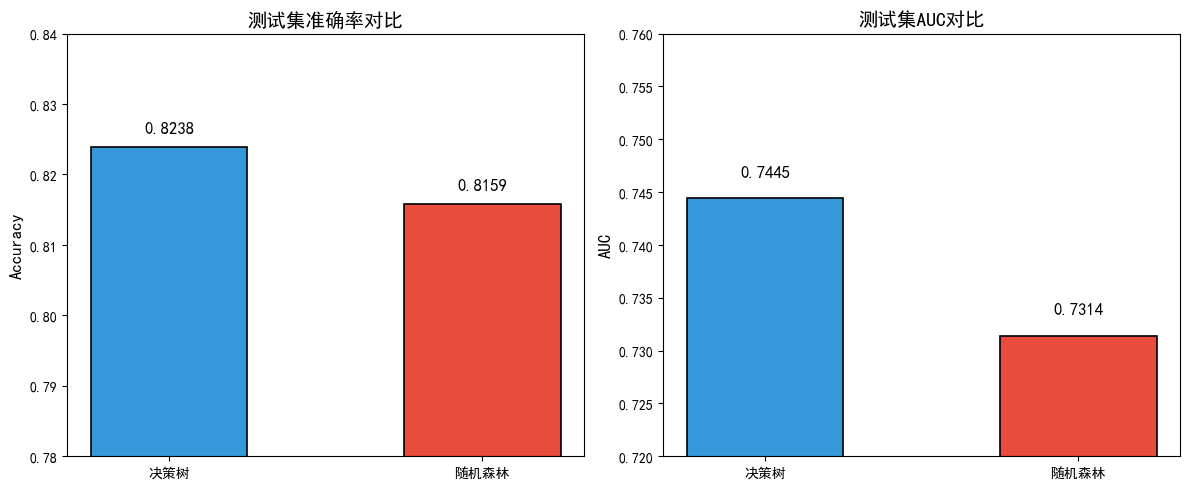

可视化完成！


In [36]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 模型性能对比
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：测试集准确率对比
models_acc = ['决策树', '随机森林']
accuracies = [rate, rate1]
colors_acc = ['#3498db', '#e74c3c']

bars1 = axes[0].bar(models_acc, accuracies, color=colors_acc, edgecolor='black', linewidth=1.2, width=0.5)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('测试集准确率对比', fontsize=14)
axes[0].set_ylim(0.78, 0.84)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# 右图：测试集AUC对比
models_auc = ['决策树', '随机森林']
aucs = [auc_score, auc_score1]
colors_auc = ['#3498db', '#e74c3c']

bars2 = axes[1].bar(models_auc, aucs, color=colors_auc, edgecolor='black', linewidth=1.2, width=0.5)
axes[1].set_ylabel('AUC', fontsize=12)
axes[1].set_title('测试集AUC对比', fontsize=14)
axes[1].set_ylim(0.72, 0.76)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("可视化完成！")

In [38]:
import numpy as np

# 网格搜索参数范围
trees_range = [5, 10, 20, 30, 50]
features_range = [3, 5, 8, 10, 12]

# 存储结果
grid_acc = np.zeros((len(trees_range), len(features_range)))
grid_auc = np.zeros((len(trees_range), len(features_range)))

print("开始网格搜索...")
print(f"树数量: {trees_range}")
print(f"特征数量: {features_range}")
print(f"共 {len(trees_range)}×{len(features_range)}={len(trees_range)*len(features_range)} 种组合\n")

for i, n_t in enumerate(trees_range):
    for j, n_f in enumerate(features_range):
        print(f"  测试 n_trees={n_t}, n_features={n_f}...")
        
        # 构建森林
        temp_tree_list = RandomForest(train_set_list, n_t, featLabels_all, n_f)
        
        # 预测
        temp_pred_list = []
        for idx in range(len(test_set_list)):
            class_list_1 = []
            for t in range(len(temp_tree_list)):
                class_label_1 = classify(temp_tree_list[t], featLabels_all, test_set_list[idx])
                class_list_1.append(class_label_1)
            temp_pred_list.append(class_list_1)
        
        # 投票
        temp_true_pred = []
        for idx in range(len(test_set_list)):
            temp_true_pred.append(list(Counter(temp_pred_list[idx]).keys())[0])
        
        # 计算指标
        temp_correct = sum(1 for idx in range(n) if temp_true_pred[idx] == y_test[idx])
        temp_acc = temp_correct / n
        temp_auc = roc_auc_score(y_test, temp_true_pred)
        
        grid_acc[i, j] = temp_acc
        grid_auc[i, j] = temp_auc
        
        print(f"    准确率: {temp_acc:.4f}, AUC: {temp_auc:.4f}")

print("\n网格搜索完成！")
print(f"最优准确率: {grid_acc.max():.4f}，参数: n_trees={trees_range[np.unravel_index(grid_acc.argmax(), grid_acc.shape)[0]]}, n_features={features_range[np.unravel_index(grid_acc.argmax(), grid_acc.shape)[1]]}")
print(f"最优AUC: {grid_auc.max():.4f}，参数: n_trees={trees_range[np.unravel_index(grid_auc.argmax(), grid_auc.shape)[0]]}, n_features={features_range[np.unravel_index(grid_auc.argmax(), grid_auc.shape)[1]]}")

开始网格搜索...
树数量: [5, 10, 20, 30, 50]
特征数量: [3, 5, 8, 10, 12]
共 5×5=25 种组合

  测试 n_trees=5, n_features=3...
第1棵树构建完成，特征: ['education-num', 'sex', 'capital-gain', 'income']
第2棵树构建完成，特征: ['native-country', 'hours-per-week', 'age', 'income']
第3棵树构建完成，特征: ['capital-loss', 'race', 'capital-gain', 'income']
第4棵树构建完成，特征: ['race', 'sex', 'relationship', 'income']
第5棵树构建完成，特征: ['marital-status', 'capital-gain', 'workclass', 'income']
    准确率: 0.7799, AUC: 0.5727
  测试 n_trees=5, n_features=5...
第1棵树构建完成，特征: ['capital-gain', 'native-country', 'age', 'marital-status', 'race', 'income']
第2棵树构建完成，特征: ['education-num', 'hours-per-week', 'age', 'native-country', 'sex', 'income']
第3棵树构建完成，特征: ['hours-per-week', 'capital-gain', 'capital-loss', 'occupation', 'native-country', 'income']
第4棵树构建完成，特征: ['education-num', 'native-country', 'marital-status', 'workclass', 'occupation', 'income']
第5棵树构建完成，特征: ['capital-gain', 'sex', 'hours-per-week', 'race', 'workclass', 'income']
    准确率: 0.7813, AUC: 0.5720
  测试 n

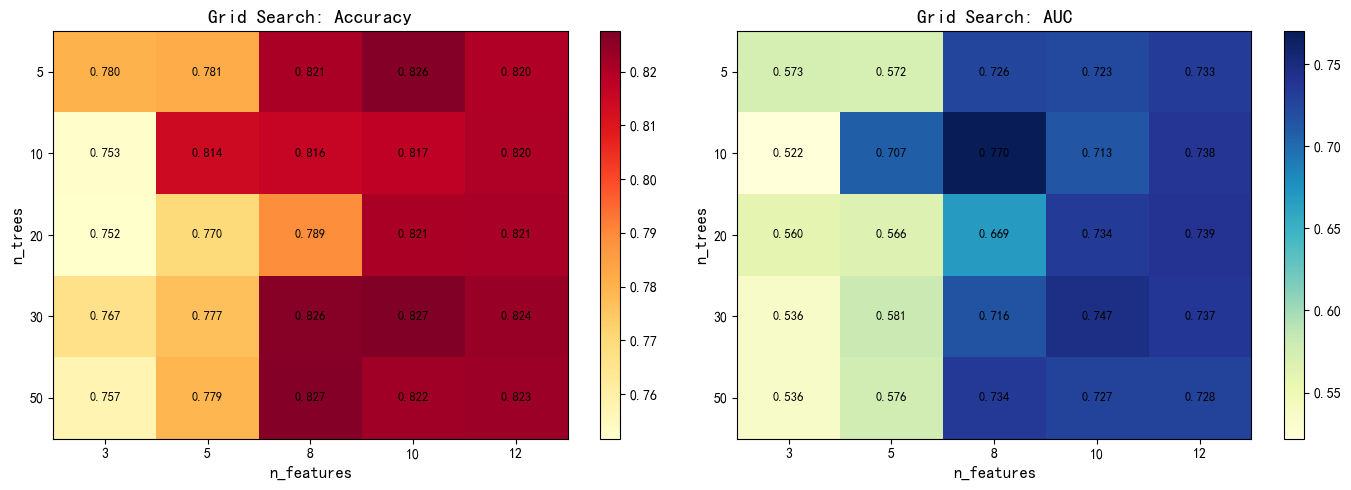

热力图完成！


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 绘制准确率热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率热力图
im1 = axes[0].imshow(grid_acc, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(features_range)))
axes[0].set_yticks(range(len(trees_range)))
axes[0].set_xticklabels(features_range)
axes[0].set_yticklabels(trees_range)
axes[0].set_xlabel('n_features', fontsize=12)
axes[0].set_ylabel('n_trees', fontsize=12)
axes[0].set_title('Grid Search: Accuracy', fontsize=14)

# 在每个格子里标注数值
for i in range(len(trees_range)):
    for j in range(len(features_range)):
        text = axes[0].text(j, i, f'{grid_acc[i, j]:.3f}',
                           ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im1, ax=axes[0])

# AUC热力图
im2 = axes[1].imshow(grid_auc, cmap='YlGnBu', aspect='auto')
axes[1].set_xticks(range(len(features_range)))
axes[1].set_yticks(range(len(trees_range)))
axes[1].set_xticklabels(features_range)
axes[1].set_yticklabels(trees_range)
axes[1].set_xlabel('n_features', fontsize=12)
axes[1].set_ylabel('n_trees', fontsize=12)
axes[1].set_title('Grid Search: AUC', fontsize=14)

for i in range(len(trees_range)):
    for j in range(len(features_range)):
        text = axes[1].text(j, i, f'{grid_auc[i, j]:.3f}',
                           ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("热力图完成！")